
# **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


# **Unit F: correlation analysis**

#### **Introduction**

The goal of this unit is to try out different statistical tests on our data set. We will quantify the linear relationship between the energy_per_hundred and the per_hundred columns by computing their correlation, and reveal the true nature of the relationship between some of these variables using visualizations. 

Finally, we will test the independence of two categorical variables statistically. We will test if the energy level in a product is associated with the country in which the product is produced. 

#### **Table of content**
1) Correlation analysis
    - a) Computing the correlations
    - b) Visualizing the correlations
2) Independence testing
    - a) Data exploration and cleaning
    - b) Statistical testing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data_clean.csv")

### **1) Correlation analysis**

#### **a) Computing the correlations**
We will start by calculating the correlation coefficients between the energy_per_hundred column and the other per_hundred columns. 

We remove the energy_kcal_per_hundred and the energy_per_hundred columns from the analysis, as their correlation coefficients are equal to 1 (they contain the same information, just in a different unit). 

In [8]:
# define the per_hundred columns
col_hundred = df.filter(regex="_per_hundred$").columns

# Compute the correlations
correlation = df[col_hundred].corr()["energy_per_hundred"]
correlation = correlation.drop(["energy_kcal_per_hundred", "energy_per_hundred"])

#### **b) Visualizing the correlations**
Now that we have our correlation coefficients, we will plot the three most highly correlated and the three less correlated features in our dataset

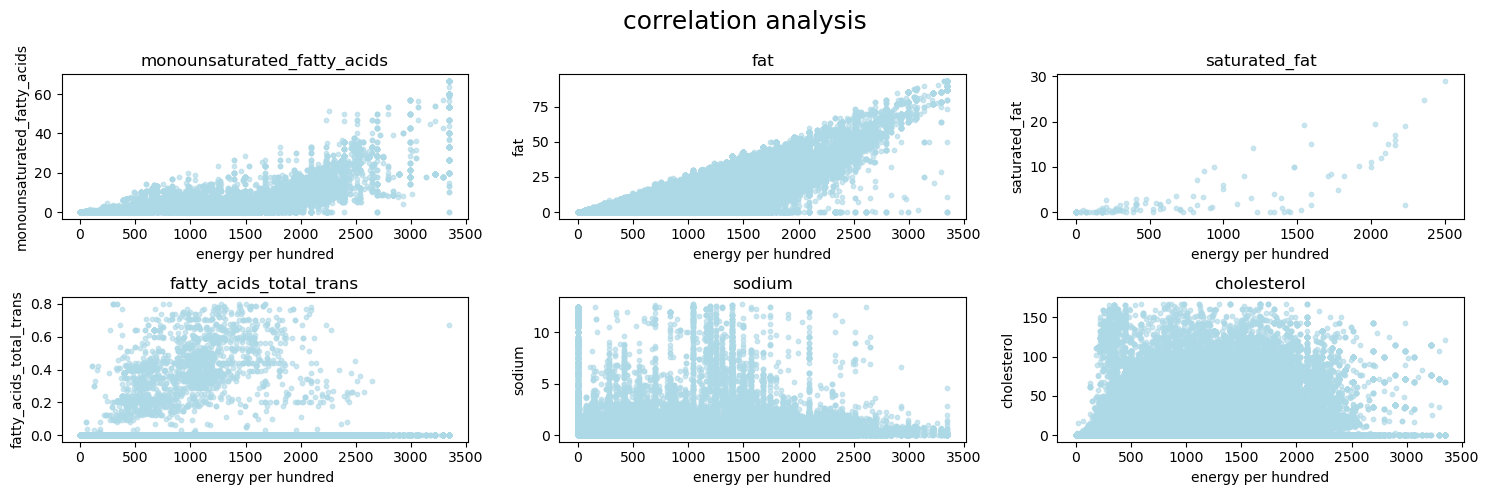

In [9]:
top_3_corr = abs(correlation).sort_values().tail(3).index
low_3_corr = abs(correlation).sort_values().head(3).index
corr_plot = top_3_corr.append(low_3_corr)

fig, axes = plt.subplots(2, 3, figsize=(15,5))
axes = axes.flatten()

for ax, name in zip(axes, corr_plot):
    ax.scatter(x=df["energy_per_hundred"], y=df[name], s=10, alpha=0.6, color="lightblue")
    ax.set_title(name.replace("_per_hundred", ""))
    ax.set_xlabel("energy per hundred")
    ax.set_ylabel(name.replace("_per_hundred", ""))

plt.suptitle("correlation analysis", fontsize=18)
plt.tight_layout()

It looks like there is a linear relationship between fat (both fat and saturated fat) contents and energy. Interestingly, the relationship between carbohydrates and energy is not linear (it first goes up, then down). This makes sense, as other nutrients (fat) contain more energy per hundred grams than carbohydrates. Thus 100g of fat will contain 0g of carbohydrates but will have more energy than 100g of only carbs. For the vitamins and iron, there is no correlation with energy, which is to be expected.

### **2) Independence testing**
We would now like to test the association between the country a food item comes from and the total energy content.

#### **a) Data exploration and cleaning**
We will first split the data into 3 categories based on the energy contained in the product. We will then explore the data and see how many entries we have for each country. 

In [20]:
# Create a clean data frame for the test
df_test = df.loc[:, ("country", "energy_per_hundred")]

# Add the energy category to the test data frame
df_test["energy_category"] = pd.qcut(df_test["energy_per_hundred"], q=3, labels=["low", "medium", "high"], duplicates='drop')

# Remove empty rows
df_test = df_test[df_test["energy_category"].notna() & df_test["country"].notna()]

# Print the number of entries per country
df_test["country"].value_counts()

US    227398
CH       223
DE         4
IT         3
Name: country, dtype: int64

We see that there are very few values for Germany and Italy. It makes sense to drop these rows from our analysis.

In [22]:
df_test = df_test[df_test.country.isin(["CH", "US"])]

#### **b) Statistical testing**

Finally, we will perform a chi square test to test if there is an association between the variable "country" and the variable "energy category". 

In [23]:
import scipy.stats as stats
# first look at the contingency table
print(pd.crosstab(df_test.energy_category, df_test.country))
# test for independence
chi_square, p_value, dof, matrix = stats.chi2_contingency(pd.crosstab(df_test.energy_category, df_test.country))

print("p_value:", p_value)

country           CH     US
energy_category            
low              129  75781
medium            63  80030
high              31  71587
p_value: 7.288986384604271e-15


#### **Analysis**

We can reject the null hypothesis, the two variables are not independent. When looking at the data, we observe that the distribution of low, medium and high caloric food is not the same in CH than in the US.